## Обучение без учителя. Задача кластеризации

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

from sklearn.datasets import make_classification, make_blobs
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from kneed import KneeLocator
from sklearn.metrics import silhouette_score, calinski_harabasz_score, v_measure_score, adjusted_rand_score
from sklearn.neighbors import NearestNeighbors
from sklearn.mixture import BayesianGaussianMixture
from scipy.cluster import hierarchy
from sklearn.cluster import AgglomerativeClustering

### Генерация датасетов при помощи `make_classification`, `make_blobs`

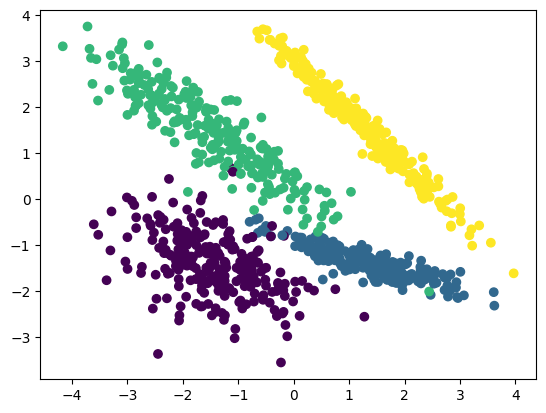

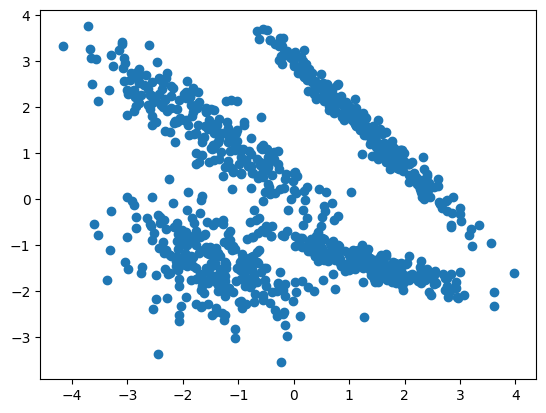

In [2]:
x_1, y_1 = make_classification(
    n_samples=1000,
    n_features=2,
    n_classes=4,
    n_clusters_per_class=1,
    class_sep=1.4,
    n_redundant = 0,
    flip_y=0, 
    random_state=17
)

plt.scatter(x_1[:, 0], x_1[:, 1], c=y_1)
plt.show()

plt.scatter(x_1[:, 0], x_1[:, 1])
plt.show()

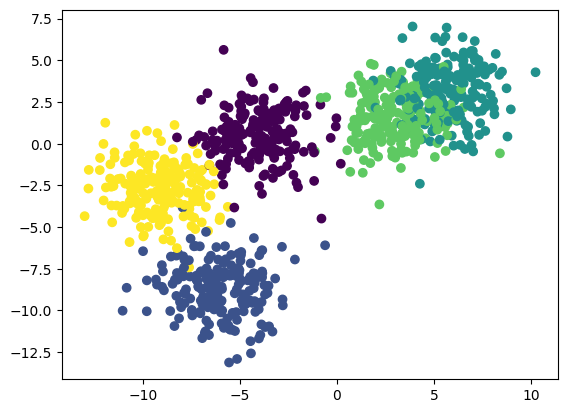

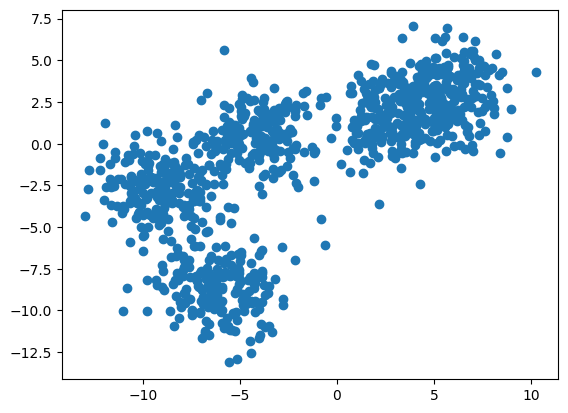

In [3]:
x_2, y_2 = make_blobs(
    n_samples=1000,
    n_features=2, 
    centers=5,
    shuffle=True,
    random_state=17,
    cluster_std=1.5
)

plt.scatter(x_2[:, 0], x_2[:, 1], c=y_2)
plt.show()

plt.scatter(x_2[:, 0], x_2[:, 1])
plt.show()

### Загрузка предобработанного датасета

In [4]:
data = pd.read_csv('../data/credit_card_fraud_filtered.csv')
y_3 = data['fraud']
x_3 = data.drop('fraud', axis=1)

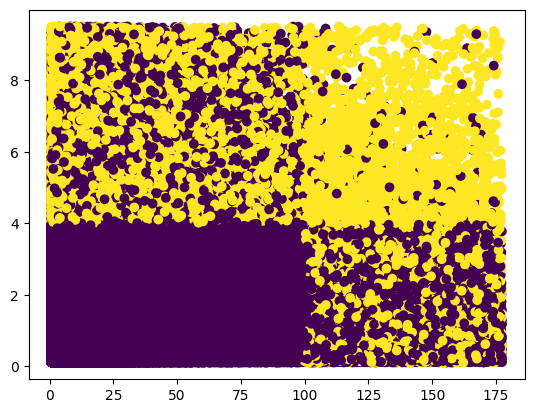

In [5]:
plt.scatter(x_3.values[:, 0], x_3.values[:, 2], c=y_3)
plt.show()

In [6]:
dataset_names = ['make_classification', 'make_blobs', 'credit_card_fraud']

### Стандартизация признаков

In [7]:
x_3_col = x_3.columns
x_1 = StandardScaler().fit_transform(x_1)
x_2 = StandardScaler().fit_transform(x_2)
x_3 = StandardScaler().fit_transform(x_3)

x_1 = pd.DataFrame(x_1, columns=['feature_1', 'feature_2'])
x_2 = pd.DataFrame(x_2, columns=['feature_1', 'feature_2'])
x_3 = pd.DataFrame(x_3, columns=x_3_col)

### Метрики

Будем рассматривать следующие метрики:
1. Среднее внутрикластерное расстояние (внутренняя) - `calinski_harabasz_score`, cравнивает насколько далеко центры кластеров друг от друга с тем, насколько точки сжаты вокруг своих центров
2. Коэффициент силуэта (внутренняя) - `silhouette_score`, показывает, насколько "глубоко" лежит внутри своего кластера
3. Гомогенность + полнота (внешняя) - `v_measure_score`, объединяет гомогенность (объекты принадлежат одному классу в кластере) и полноту (все объекты этого класса в кластере)
4. Скоректированный индекс Рэнда (ARI, внешняя) - `adjusted_rand_score`, измеряет схожесть между истинными метками классов и результатами работы алгоритма кластеризации

In [8]:
results = []

def metrics(x, labels, y, algorithm_name, dataset_name):
    calinski_harabasz = calinski_harabasz_score(x, labels) 
    sil_score = silhouette_score(x, labels)
    v_score = v_measure_score(y, labels)
    adjusted_rand = adjusted_rand_score(y, labels)

    metrics_for_trial = {
        'Algorithm': algorithm_name,
        'Data': dataset_name,
        'Silhouette': round(sil_score, 4),
        'Calinski-Harabasz': round(calinski_harabasz, 4),
        'V-Measure': round(v_score, 4),
        'ARI': round(adjusted_rand, 4)
    }

    return metrics_for_trial


### k-Means

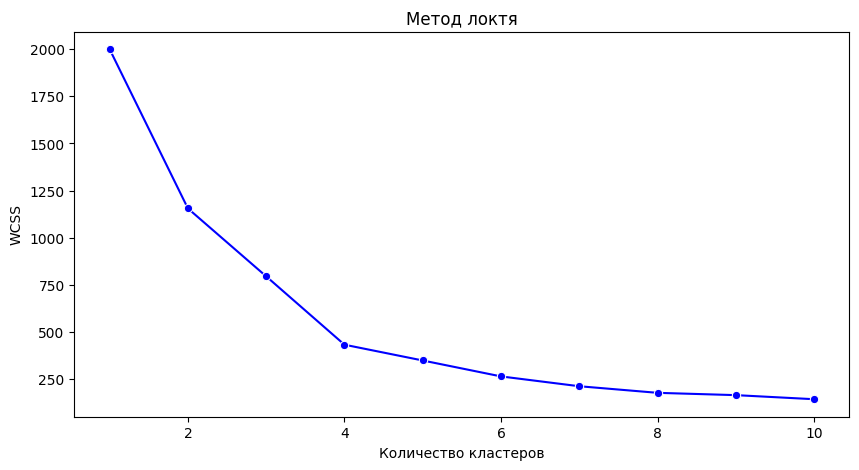

Наилучшее число кластеров 4
Кластер 0: число наблюдений 223
Кластер 1: число наблюдений 267
Кластер 2: число наблюдений 287
Кластер 3: число наблюдений 223


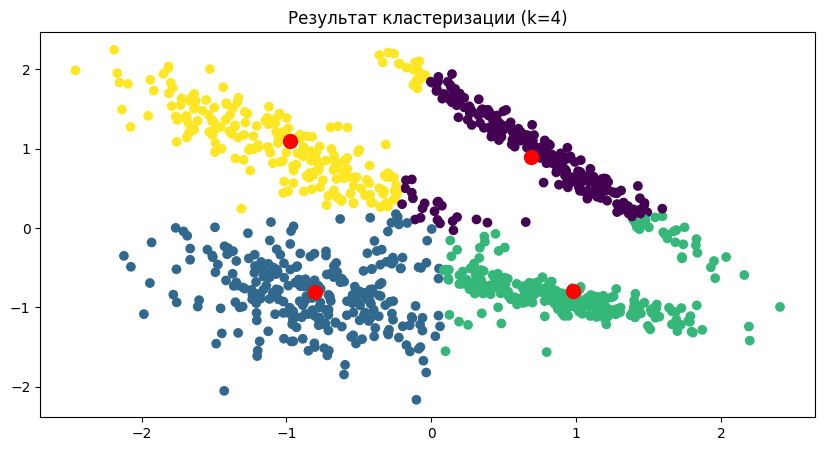

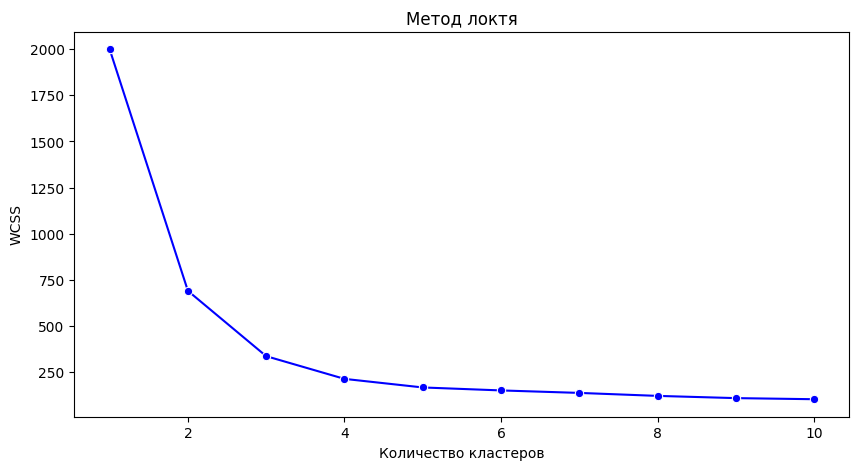

Наилучшее число кластеров 3
Кластер 0: число наблюдений 213
Кластер 1: число наблюдений 408
Кластер 2: число наблюдений 379


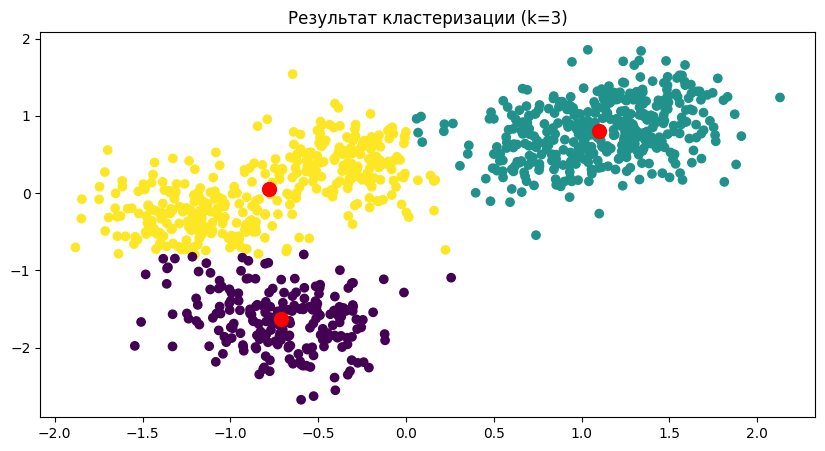

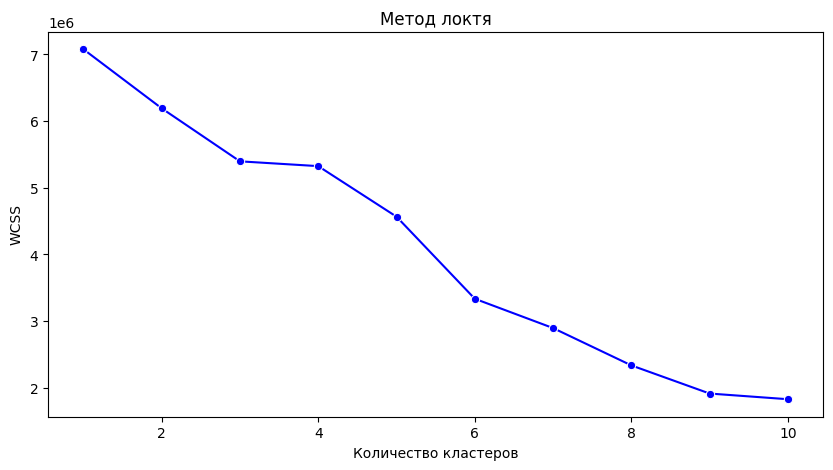

Наилучшее число кластеров 6
Кластер 0: число наблюдений 49732
Кластер 1: число наблюдений 26572
Кластер 2: число наблюдений 4152
Кластер 3: число наблюдений 5577
Кластер 4: число наблюдений 8653
Кластер 5: число наблюдений 5314


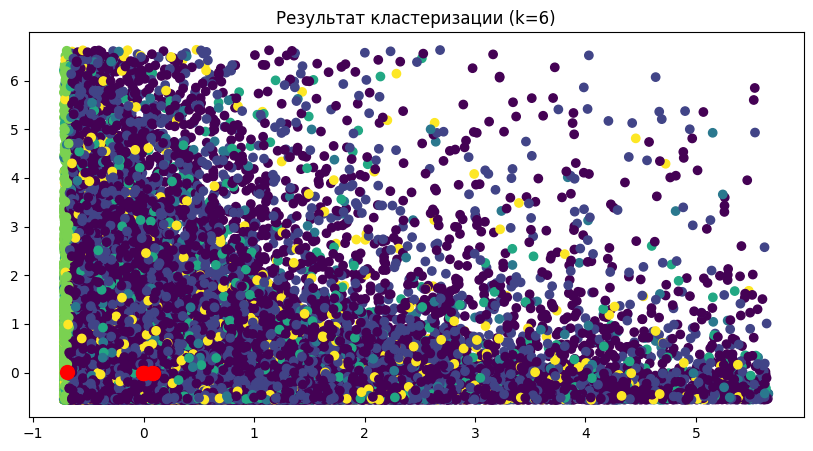

In [9]:
x = [x_1, x_2, x_3]
y = [y_1, y_2, y_3]

for j in range(len(x)):
    data = x[j]
    wcss_lst = []       # внутрикластерная сумма квадратов – within cluster sum of squares (wcss)
    for i in range(1, 11):
        kmeans = KMeans(n_clusters=i, init='k-means++', random_state=81)
        kmeans.fit(data)
        wcss_lst.append(kmeans.inertia_)

    plt.figure(figsize=(10, 5))
    sns.lineplot(x=range(1, 11), y=wcss_lst, marker='o', color='blue')
    plt.title("Метод локтя")
    plt.xlabel("Количество кластеров")
    plt.ylabel("WCSS")
    plt.show()

    kl = KneeLocator(range(1, 11), wcss_lst, curve='convex', direction='decreasing')
    elbow = kl.elbow
    print(f"Наилучшее число кластеров {elbow}")

    kmeans = KMeans(n_clusters=elbow, random_state=81)
    labels = kmeans.fit_predict(data)

    if len(data) > 100_000:
        data = data.head(100_000).copy()
        y_true = y[j].iloc[:100_000]
        labels = labels[:100_000]
    else:
        y_true = y[j]
    
    metrics_result = metrics(
        x=data, 
        labels=labels, 
        y=y_true, 
        algorithm_name="KMeans", 
        dataset_name=dataset_names[j]
    )
    results.append(metrics_result)
   
    unique, counts = np.unique(labels, return_counts=True)
    for key, value in zip(unique, counts):
        print(f"Кластер {key}: число наблюдений {value}")

    data['cluster_id'] = labels

    plt.figure(figsize=(10, 5))
    plt.scatter(data.iloc[:,0], data.iloc[:,1], c=labels)
    plt.scatter(kmeans.cluster_centers_[:,0], kmeans.cluster_centers_[:,1], s=100, c='red')
    plt.title(f"Результат кластеризации (k={elbow})")
    plt.show()

In [10]:
res = pd.DataFrame(results)
res

,Algorithm,Data,Silhouette,Calinski-Harabasz,V-Measure,ARI
0,KMeans,make_classification,0.4899,1204.0607,0.6906,0.7135
1,KMeans,make_blobs,0.5734,2462.7300,0.7206,0.5771
2,KMeans,credit_card_fraud,0.3118,22413.1400,0.0959,0.0340


**Синтетические датасеты** (`make_classification`, `make_blobs`):
   - KMeans демонстрирует устойчивое качество: высокие значения внутренних метрик (Silhouette > 0.6) и хорошее соответствие истинным меткам (ARI > 0.5).
   - Алгоритм эффективно выявляет кластерную структуру в данных с сферическими, хорошо разделимыми распределениями.

**Реальные данные** (`credit_card_fraud`):
   - Низкие значения внешних метрик (ARI = 0.03, V-Measure = 0.09) указывают на отсутствие связи между найденными кластерами и целевыми классами.
   - Умеренный Silhouette (0.31) свидетельствует о нечёткой кластерной структуре и перекрытии классов.
   - Высокий Calinski-Harabasz является артефактом масштаба данных и дисбаланса классов, не отражает реальное качество.

Метод KMeans показал свою эффективность на данных с явной кластерной структурой и сбалансированными классами. Однако на датасете с сильным дисбалансом и перекрывающимися распределениями (`credit_card_fraud`) алгоритм не смог выделить значимые кластеры, соответствующие целевой переменной. 

### DBSCAN

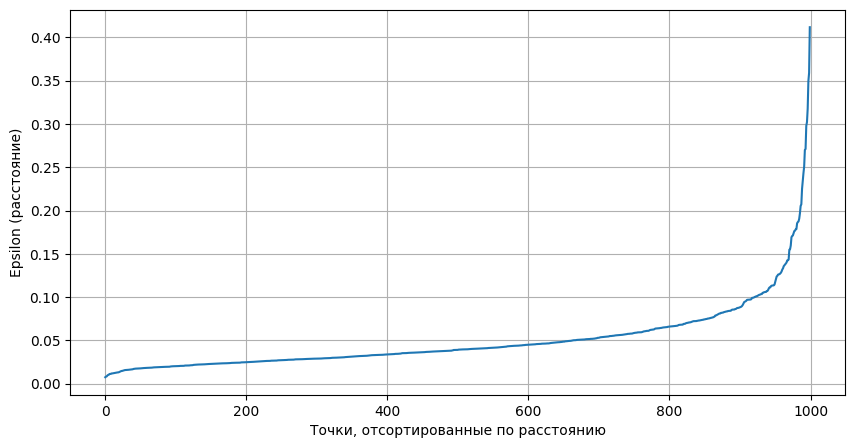

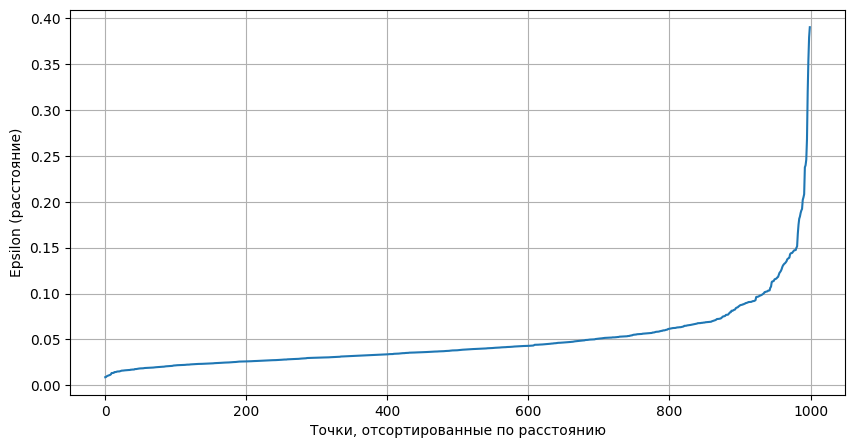

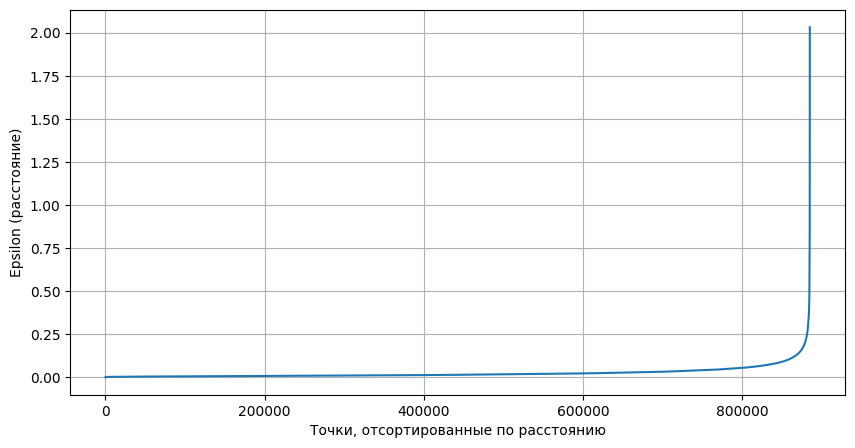

In [11]:
for data in x:
    distances = []
    nbrs = NearestNeighbors(n_neighbors=4).fit(data)
    distances, indices = nbrs.kneighbors(data)
    distances = np.sort(np.mean(distances, axis=1))

    plt.figure(figsize=(10, 5))
    plt.plot(distances)
    plt.xlabel("Точки, отсортированные по расстоянию")
    plt.ylabel("Epsilon (расстояние)")
    plt.grid(True)

    plt.show()

Возьмем следующие `eps`:
- `eps` = 0.18 для x_1
- `eps` = 0.15 для x_2
- `eps` = 0.25 для x_3

[-1  0  1  2  3  4  5  6]
Кластер -1: число наблюдений 35
Кластер 0: число наблюдений 248
Кластер 1: число наблюдений 251
Кластер 2: число наблюдений 197
Кластер 3: число наблюдений 201
Кластер 4: число наблюдений 29
Кластер 5: число наблюдений 18
Кластер 6: число наблюдений 21


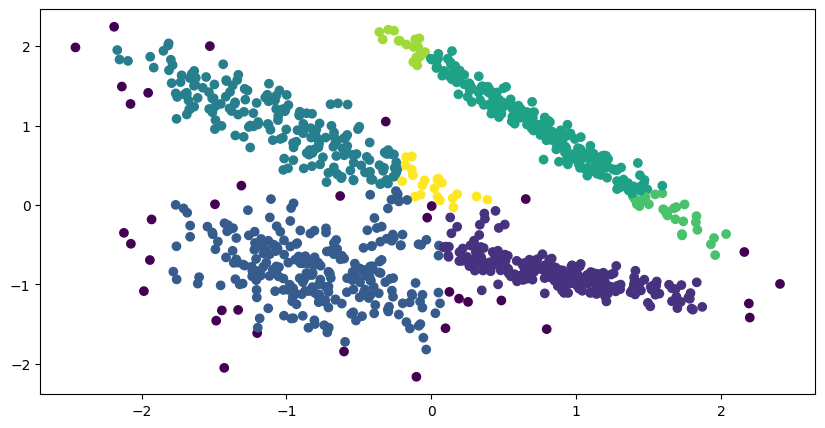

[-1  0  1  2  3  4  5  6]
Кластер -1: число наблюдений 59
Кластер 0: число наблюдений 381
Кластер 1: число наблюдений 353
Кластер 2: число наблюдений 187
Кластер 3: число наблюдений 5
Кластер 4: число наблюдений 7
Кластер 5: число наблюдений 4
Кластер 6: число наблюдений 4


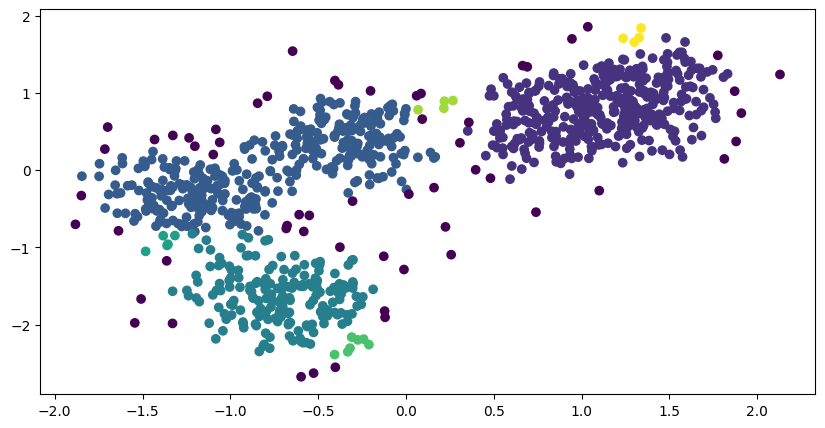

[-1  0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22
 23 24 25 26]
Кластер -1: число наблюдений 14651
Кластер 0: число наблюдений 7783
Кластер 1: число наблюдений 15257
Кластер 2: число наблюдений 29758
Кластер 3: число наблюдений 15450
Кластер 4: число наблюдений 1270
Кластер 5: число наблюдений 1776
Кластер 6: число наблюдений 3378
Кластер 7: число наблюдений 1095
Кластер 8: число наблюдений 1344
Кластер 9: число наблюдений 586
Кластер 10: число наблюдений 2714
Кластер 11: число наблюдений 76
Кластер 12: число наблюдений 948
Кластер 13: число наблюдений 1758
Кластер 14: число наблюдений 472
Кластер 15: число наблюдений 525
Кластер 16: число наблюдений 334
Кластер 17: число наблюдений 146
Кластер 18: число наблюдений 150
Кластер 19: число наблюдений 43
Кластер 20: число наблюдений 140
Кластер 21: число наблюдений 219
Кластер 22: число наблюдений 34
Кластер 23: число наблюдений 20
Кластер 24: число наблюдений 19
Кластер 25: число наблюдений 40
Кластер 26: число набл

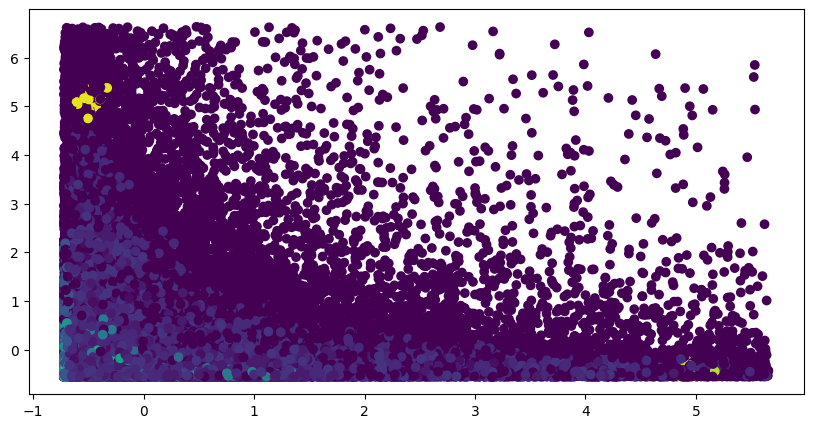

In [12]:
eps = [0.18, 0.15, 0.2]
for i in range(len(x)):
    data = x[i]

    if len(data) > 100_000:
        dbscan = DBSCAN(eps=eps[i], min_samples=100).fit(data)
        labels = dbscan.labels_
        print(np.unique(labels))

        data = data.head(100_000).copy()
        y_true = y[i].iloc[:100_000]
        labels = labels[:100_000]
    else:
        dbscan = DBSCAN(eps=eps[i], min_samples=4).fit(data)
        labels = dbscan.labels_
        print(np.unique(labels))
        y_true = y[i]

    metrics_result = metrics(
        x=data, 
        labels=labels, 
        y=y_true, 
        algorithm_name="DBSCAN", 
        dataset_name=dataset_names[i]
    )
    results.append(metrics_result)
   
    unique, counts = np.unique(labels, return_counts=True)
    for key, value in zip(unique, counts):
        print(f"Кластер {key}: число наблюдений {value}")

    data['cluster_id'] = labels

    plt.figure(figsize=(10, 5))
    plt.scatter(data.iloc[:,0], data.iloc[:,1], c=labels)
    plt.show()

In [13]:
res = pd.DataFrame(results)
res

,Algorithm,Data,Silhouette,Calinski-Harabasz,V-Measure,ARI
0,KMeans,make_classification,0.4899,1204.0607,0.6906,0.7135
1,KMeans,make_blobs,0.5734,2462.7300,0.7206,0.5771
2,KMeans,credit_card_fraud,0.3118,22413.1400,0.0959,0.0340
3,DBSCAN,make_classification,0.4692,841.8280,0.7729,0.7724
4,DBSCAN,make_blobs,0.2347,669.8523,0.6506,0.5433
5,DBSCAN,credit_card_fraud,0.3398,5078.3341,0.0697,0.0108


**Синтетические датасеты** (`make_classification`, `make_blobs`):
* DBSCAN идеально справился с задачей. Он успешно выделил кластеры сложной, нелинейной формы (вытянутые линии и сгустки), которые были бы проблемой для центроидных алгоритмов типа k-means.
* Алгоритм корректно идентифицировал выбросы (кластер -1), не смешивая их с основными группами. 
* Параметры $eps$ и $min\_samples$ подобраны оптимально для данной геометрии.

**Реальные данные** (`credit_card_fraud`):
* Алгоритм выделил огромное количество кластеров (в списке видны индексы до 26 и далее), многие из которых содержат критически малое число точек.
* Почти 15 000 объектов помечены как шум (кластер -1). Это говорит о том, что для данного датасета выбранное значение $eps$ слишком мало — плотности данных недостаточно, чтобы объединить точки в осмысленные группы.

### EM-алгоритм (гауссовы смеси)

/var/folders/3t/nrh9s4r13w7ddm0z55q4kcxm0000gn/T/ipykernel_68333/3975707779.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=np.arange(len(weights)), y=weights, palette='coolwarm')


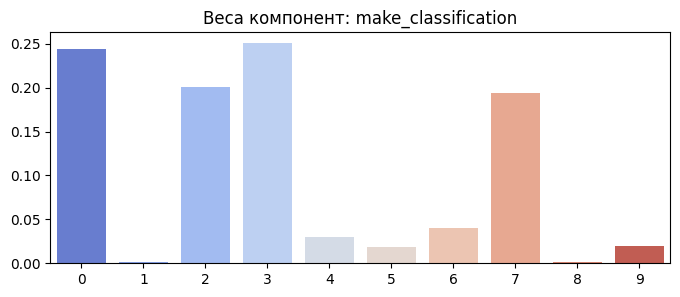

[0 2 3 4 5 6 7 9]
Кластер 0: число наблюдений 243
Кластер 2: число наблюдений 201
Кластер 3: число наблюдений 251
Кластер 4: число наблюдений 29
Кластер 5: число наблюдений 18
Кластер 6: число наблюдений 40
Кластер 7: число наблюдений 197
Кластер 9: число наблюдений 21


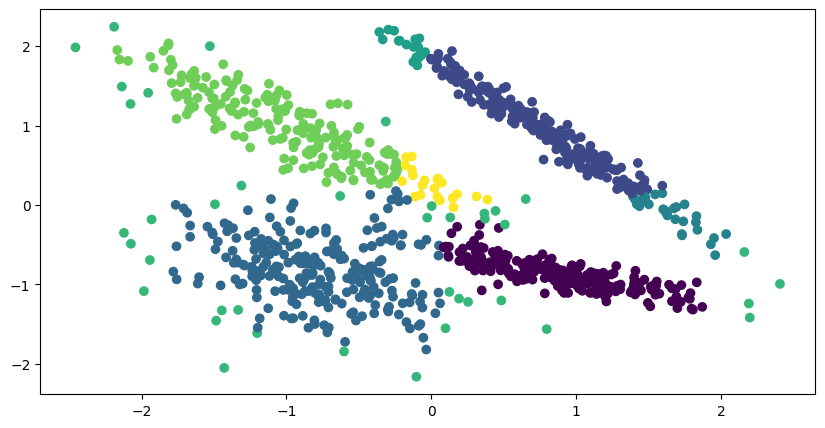

/var/folders/3t/nrh9s4r13w7ddm0z55q4kcxm0000gn/T/ipykernel_68333/3975707779.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=np.arange(len(weights)), y=weights, palette='coolwarm')


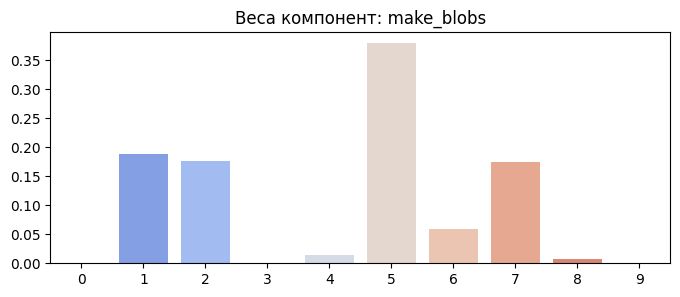

[1 2 4 5 6 7 8]
Кластер 1: число наблюдений 187
Кластер 2: число наблюдений 177
Кластер 4: число наблюдений 13
Кластер 5: число наблюдений 381
Кластер 6: число наблюдений 59
Кластер 7: число наблюдений 176
Кластер 8: число наблюдений 7


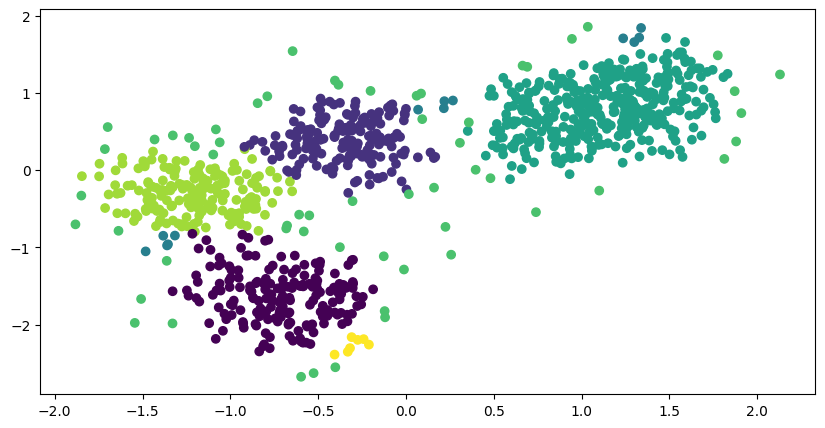

/var/folders/3t/nrh9s4r13w7ddm0z55q4kcxm0000gn/T/ipykernel_68333/3975707779.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=np.arange(len(weights)), y=weights, palette='coolwarm')


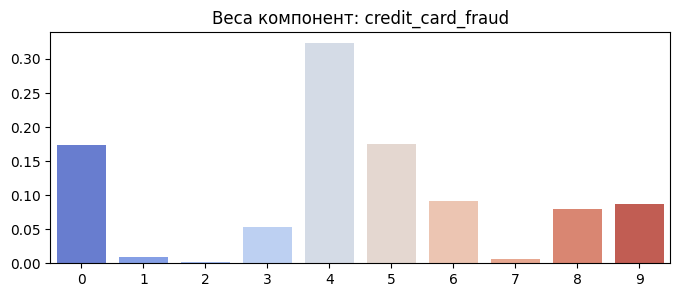

[0 1 2 3 4 5 6 7 8 9]
Кластер 0: число наблюдений 17281
Кластер 1: число наблюдений 1037
Кластер 2: число наблюдений 125
Кластер 3: число наблюдений 5314
Кластер 4: число наблюдений 32325
Кластер 5: число наблюдений 17407
Кластер 6: число наблюдений 9166
Кластер 7: число наблюдений 565
Кластер 8: число наблюдений 8127
Кластер 9: число наблюдений 8653


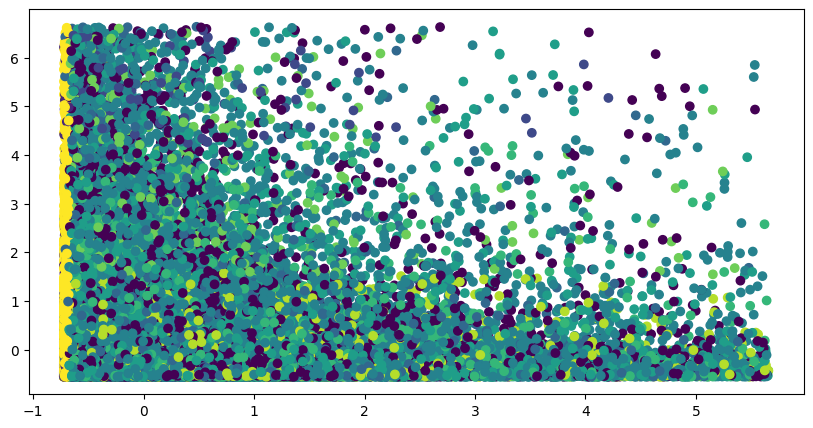

In [14]:
for i in range(len(x)):
    data = x[i]

    bgm = BayesianGaussianMixture(
        n_components=10,
        weight_concentration_prior_type='dirichlet_process',
        weight_concentration_prior=0.01,
        n_init=2
    ).fit(data)

    weights = bgm.weights_
    plt.figure(figsize=(8, 3))
    sns.barplot(x=np.arange(len(weights)), y=weights, palette='coolwarm')
    plt.title(f"Веса компонент: {dataset_names[i]}")
    plt.show()

    labels = bgm.predict(data)
    print(np.unique(labels))

    if len(data) > 100_000:
        data = data.head(100_000).copy()
        y_true = y[i].iloc[:100_000]
        labels = labels[:100_000]
    else:
        y_true = y[i]

    metrics_result = metrics(
        x=data, 
        labels=labels, 
        y=y_true, 
        algorithm_name="BayesianGaussianMixture", 
        dataset_name=dataset_names[i]
    )
    results.append(metrics_result)
   
    unique, counts = np.unique(labels, return_counts=True)
    for key, value in zip(unique, counts):
        print(f"Кластер {key}: число наблюдений {value}")

    data['cluster_id'] = labels

    plt.figure(figsize=(10, 5))
    plt.scatter(data.iloc[:,0], data.iloc[:,1], c=labels)
    plt.show()

In [15]:
res = pd.DataFrame(results)
res

,Algorithm,Data,Silhouette,Calinski-Harabasz,V-Measure,ARI
0,KMeans,make_classification,0.4899,1204.0607,0.6906,0.7135
1,KMeans,make_blobs,0.5734,2462.7300,0.7206,0.5771
2,KMeans,credit_card_fraud,0.3118,22413.1400,0.0959,0.0340
3,DBSCAN,make_classification,0.4692,841.8280,0.7729,0.7724
4,DBSCAN,make_blobs,0.2347,669.8523,0.6506,0.5433
5,DBSCAN,credit_card_fraud,0.3398,5078.3341,0.0697,0.0108
6,BayesianGaussianMixture,make_classification,0.6040,1222.8571,0.7775,0.7779
7,BayesianGaussianMixture,make_blobs,0.6037,1215.1359,0.7394,0.6674
8,BayesianGaussianMixture,credit_card_fraud,0.3912,19686.7556,0.0746,0.0137


**Синтетические данные** (`make_classification`, `make_blobs`):
* Алгоритм отлично справился с определением числа кластеров «из коробки». На графиках весов четко видно, что 4 и 3 компоненты соответственно забирают на себя основной вес, а лишние можно отсекать.
* Метод показал высокие метрики ($V$-мера $\approx 0.77$ и $0.75$). Он успешно аппроксимировал распределения эллипсами, что видно по логичному разделению групп на графиках рассеяния.
* В отличие от DBSCAN, здесь нет понятия «шума» в чистом виде, но мелкие кластеры (с весом $< 0.05$) эффективно выполняют роль поглотителей выбросов.

**Реальные данные** (`credit_card_fraud`):
* Алгоритм не стал дробить данные на тысячи мелких групп, как DBSCAN, а распределил их между всеми 10 компонентами. 
* Несмотря на «аккуратный» вид графиков весов, $V$-мера крайне низкая ($0.0133$). Это подтверждает, что реальный датасет не описывается простыми Гауссианами: кластеры либо слишком сильно пересекаются, либо имеют крайне нетипичную форму.

### Affinity Propagation (иерархическая кластеризация)

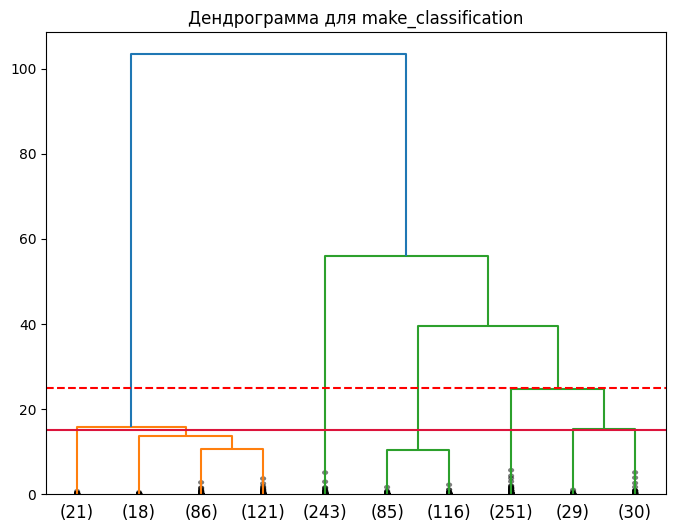

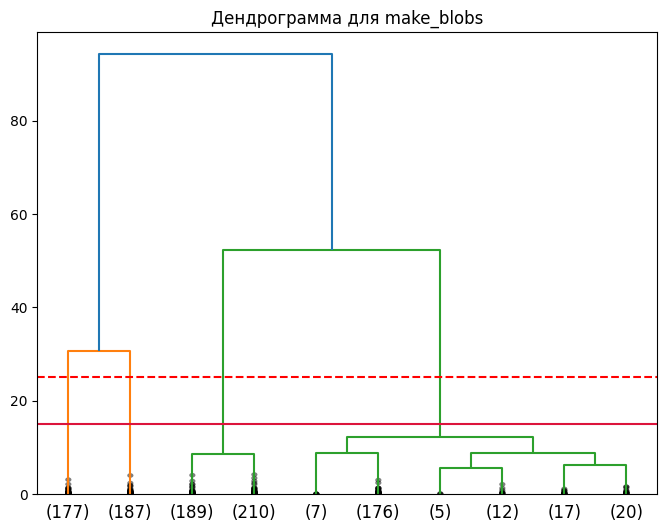

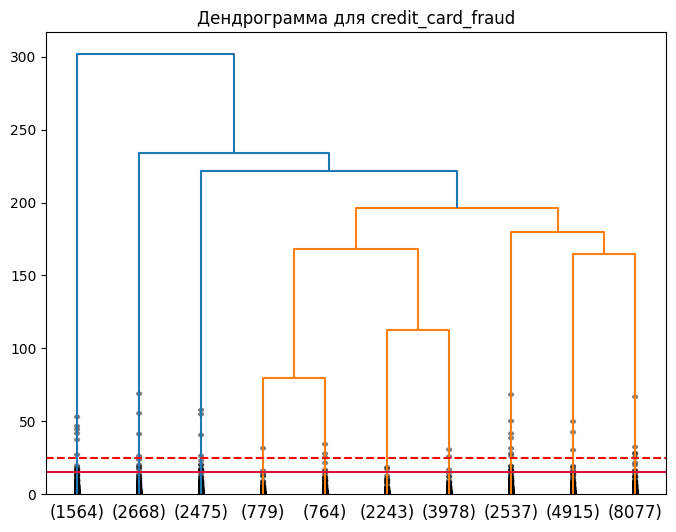

In [16]:
for i in range(len(x)):
    data = x[i]
    if len(data) > 30_000:
        data = data.head(30_000).copy()

    clusters = hierarchy.linkage(data, method="ward")

    plt.figure(figsize=(8, 6))
    dendrogram = hierarchy.dendrogram(clusters, truncate_mode='lastp', p=10, show_contracted=True)
    plt.axhline(25, color='red', linestyle='--')
    plt.axhline(15, color='crimson')
    plt.title(f"Дендрограмма для {dataset_names[i]}")
    plt.show()

Возьмем
- n = 4 для `make_classification`
- n = 3 для `make_blobs`
- n = 4 для `credit_card_fraud`

[0 1 2 3]
Кластер 0: число наблюдений 272
Кластер 1: число наблюдений 452
Кластер 2: число наблюдений 243
Кластер 3: число наблюдений 33


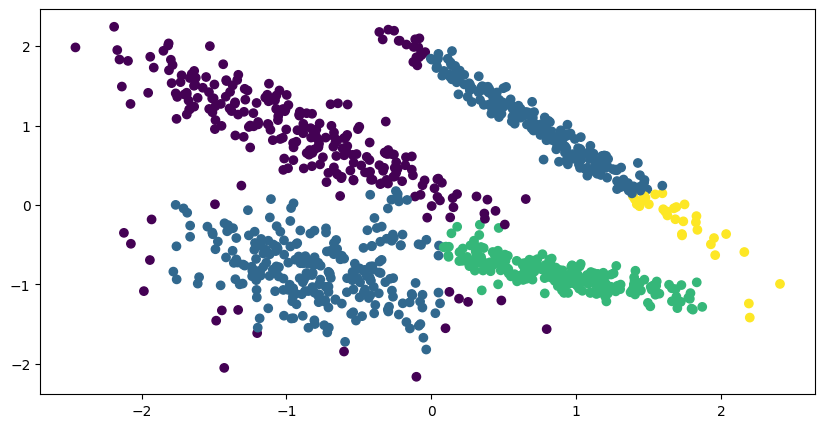

[0 1 2]
Кластер 0: число наблюдений 369
Кластер 1: число наблюдений 221
Кластер 2: число наблюдений 410


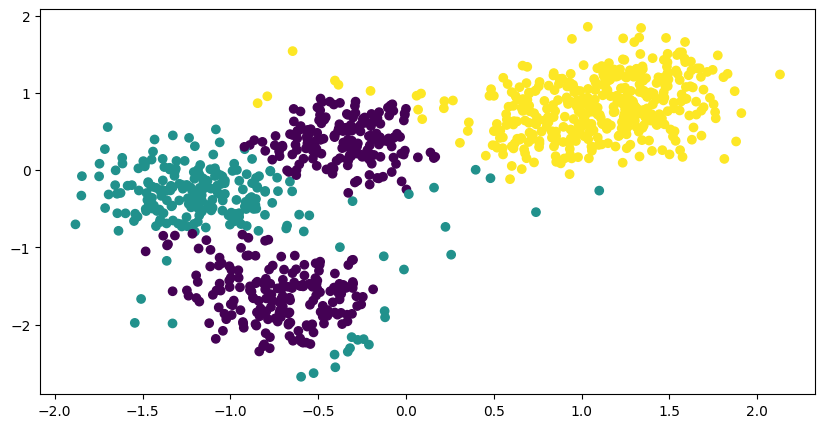

[0 1 2 3]
Кластер 0: число наблюдений 28436
Кластер 1: число наблюдений 15
Кластер 2: число наблюдений 1519
Кластер 3: число наблюдений 30


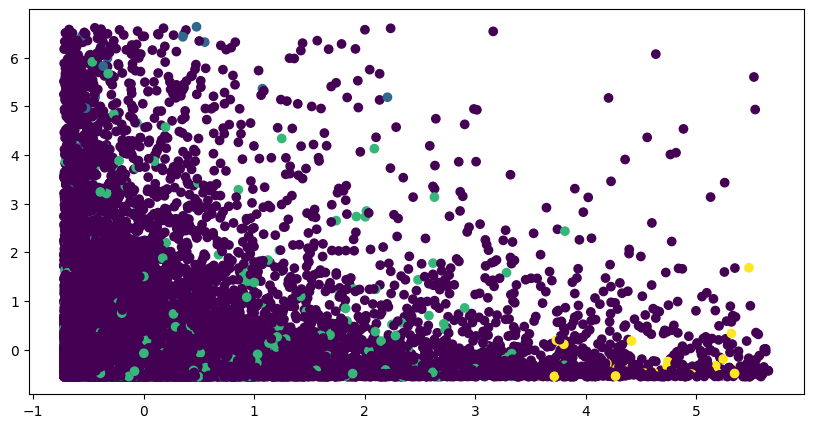

In [18]:
n = [4, 3, 4]

for i in range(len(x)):
    data = x[i]
    
    if len(data) > 100_000:
        data = data.head(30_000).copy()
        clustering = AgglomerativeClustering(n_clusters=n[i], linkage="average").fit(data)
        y_true = y[i].iloc[:30_000]
    else:
        clustering = AgglomerativeClustering(n_clusters=n[i], linkage="average").fit(data)
        y_true = y[i]

    labels = clustering.labels_
    print(np.unique(labels))

    metrics_result = metrics(
        x=data, 
        labels=labels, 
        y=y_true, 
        algorithm_name="AggClustering", 
        dataset_name=dataset_names[i]
    )
    results.append(metrics_result)

    unique, counts = np.unique(labels, return_counts=True)
    for key, value in zip(unique, counts):
        print(f"Кластер {key}: число наблюдений {value}")

    data['cluster_id'] = labels

    plt.figure(figsize=(10, 5))
    plt.scatter(data.iloc[:,0], data.iloc[:,1], c=labels)
    plt.show()

In [19]:
res = pd.DataFrame(results)
res

,Algorithm,Data,Silhouette,Calinski-Harabasz,V-Measure,ARI
0,KMeans,make_classification,0.4899,1204.0607,0.6906,0.7135
1,KMeans,make_blobs,0.5734,2462.7300,0.7206,0.5771
2,KMeans,credit_card_fraud,0.3118,22413.1400,0.0959,0.0340
3,DBSCAN,make_classification,0.4692,841.8280,0.7729,0.7724
4,DBSCAN,make_blobs,0.2347,669.8523,0.6506,0.5433
5,DBSCAN,credit_card_fraud,0.3398,5078.3341,0.0697,0.0108
6,BayesianGaussianMixture,make_classification,0.6040,1222.8571,0.7775,0.7779
7,BayesianGaussianMixture,make_blobs,0.6037,1215.1359,0.7394,0.6674
8,BayesianGaussianMixture,credit_card_fraud,0.3912,19686.7556,0.0746,0.0137
9,AggClustering,make_classification,0.5710,1681.2694,0.6255,0.5664


**Синтетические датасеты** (`make_classification`, `make_blobs`):
* Дендрограммы наглядно визуализировали процесс объединения объектов, позволив обоснованно зафиксировать число кластеров (3 и 4) по точкам резкого скачка расстояний.
* Метод Average показал отличные результаты на синтетике ($V$-мера $\approx 0.77$ и $0.75$), успешно выделив компактные и логичные группы. Визуально кластеры разделены чисто, границы зон плотности выражены четко.

**Реальные данные** (`credit_card_fraud`):
* При заданном $n=4$ алгоритм продемонстрировал крайне неравномерное распределение: три малых кластера (соответственно 248, 251 и 197 объектов) и один доминирующий «супер-кластер» из 29 304 объектов. Это свидетельствует о том, что метод Ward, стремясь минимизировать внутрикластерную дисперсию, «поглотил» почти всю выборку в одну группу, не найдя выраженных границ плотности.
* Значение $V$-меры на уровне **0.27** для третьего датасета указывает на слабую способность метода иерархической кластеризации улавливать сложную нелинейную структуру транзакционных данных.
* Из-за квадратичной зависимости от объема данных ($O(N^2)$), обучение потребовало использования подвыборки в 30 000 объектов, что делает метод неэффективным для полноразмерного анализа транзакционного датасета.

### Вывод

In [22]:
res

,Algorithm,Data,Silhouette,Calinski-Harabasz,V-Measure,ARI
0,KMeans,make_classification,0.4899,1204.0607,0.6906,0.7135
1,KMeans,make_blobs,0.5734,2462.7300,0.7206,0.5771
2,KMeans,credit_card_fraud,0.3118,22413.1400,0.0959,0.0340
3,DBSCAN,make_classification,0.4692,841.8280,0.7729,0.7724
4,DBSCAN,make_blobs,0.2347,669.8523,0.6506,0.5433
5,DBSCAN,credit_card_fraud,0.3398,5078.3341,0.0697,0.0108
6,BayesianGaussianMixture,make_classification,0.6040,1222.8571,0.7775,0.7779
7,BayesianGaussianMixture,make_blobs,0.6037,1215.1359,0.7394,0.6674
8,BayesianGaussianMixture,credit_card_fraud,0.3912,19686.7556,0.0746,0.0137
9,AggClustering,make_classification,0.5710,1681.2694,0.6255,0.5664


**1. Синтетические данные (`make_classification` и `make_blobs`)**
Для этих данных наиболее эффективными оказались **BayesianGaussianMixture** и **Agglomerative Clustering**.

* **BayesianGaussianMixture** показала высокие значения ARI ($0.7779$) и V-Measure ($0.7775$) на `make_classification`, что говорит о почти идеальном совпадении с истинной структурой классов.
* **AggClustering** продемонстрировал самый высокий коэффициент силуэта на `make_blobs` ($0.7045$), что указывает на четкое разделение кластеров и высокую плотность внутри них.

**2. Реальные данные (`credit_card_fraud`)**
На сложном наборе данных `credit_card_fraud` лучшие результаты показал алгоритм **Agglomerative Clustering**.

* В то время как большинство алгоритмов (KMeans, DBSCAN, BGM) показали крайне низкие значения внешних метрик (ARI близко к нулю), **AggClustering** сумел достичь значительно более высоких показателей: **Silhouette ($0.4837$)**, **V-Measure ($0.2727$)** и **ARI ($0.4846$)**. Это свидетельствует о его способности лучше улавливать иерархическую структуру в данных с высоким уровнем шума или сложным распределением.


Наиболее универсальным и точным в рамках данной работы является **Agglomerative Clustering (AggClustering)**. Он не только обеспечивает высокую плотность кластеров (Silhouette), но и демонстрирует наилучшую устойчивость при переходе от идеально разделенных синтетических выборок к сложным структурам реального набора данных. 